# Logistic Regression Project: Diabetes Prediction

**Project Title:** Diabetes Prediction using Kaggle Data  
**Student Name:** [Your Name]  
**Date:** [Current Date]  
**Dataset:** Pima Indians Diabetes Database (`diabetes.csv` from Kaggle)  
**Objective:** Predict Outcome ($0 =$ No diabetes, $1 =$ Diabetes) using balanced Logistic Regression with median imputation and standard scaling.

## 1. Project Overview & Workflow

**Dataset Features:**
- `Pregnancies`: Number of times pregnant
- `Glucose`: Plasma glucose concentration
- `BloodPressure`: Diastolic blood pressure (mm Hg)
- `SkinThickness`: Triceps skin fold thickness (mm)
- `Insulin`: 2-Hour serum insulin (mu U/ml)
- `BMI`: Body mass index (weight in kg/(height in m)^2)
- `DiabetesPedigreeFunction`: Diabetes pedigree function
- `Age`: Age (years)
- `Outcome`: Class variable (0 or 1)

**Complete Workflow:**
1. Load Kaggle CSV dataset (`diabetes.csv` or URL fallback).
2. Inspect data structure and missing/invalid values.
3. Replace invalid zero values with `NaN` in physiological features.
4. Perform Train-Test Split prior to preprocessing to prevent data leakage.
5. Apply Median Imputation to replace missing values.
6. Standardize numerical features using `StandardScaler`.
7. Train a class-balanced Logistic Regression model.
8. Evaluate performance metrics (Accuracy, Precision, Recall, F1-Score, ROC-AUC, Confusion Matrix).
9. Interpret feature importance via Logistic Regression coefficients.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# Load dataset (Direct GitHub raw URL fallback if local diabetes.csv isn't present)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
col_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

try:
    df = pd.read_csv('diabetes.csv')
except FileNotFoundError:
    df = pd.read_csv(url, names=col_names)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Data Preprocessing & Invalid Zero Treatment

In biological attributes like `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI`, a zero reading represents an invalid/missing value rather than a genuine measure of zero.

In [2]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Zero value counts before replacement:")
print((df[zero_cols] == 0).sum())

# Replace invalid zeros with NaN
df[zero_cols] = df[zero_cols].replace(0, np.nan)

print("\nNaN count after replacing invalid zeros:")
print(df.isnull().sum())

Zero value counts before replacement:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

NaN count after replacing invalid zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


## 3. Train-Test Split, Imputation & Scaling

To prevent data leakage, imputation and standardization transformers are fitted **only** on the training split.

In [3]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# Train-Test Split (fixed random state for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Median Imputation
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# Standard Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")

Training set shape: (614, 8)
Testing set shape: (154, 8)


## 4. Logistic Regression Model Training

In [4]:
# Balanced Logistic Regression to handle class imbalance
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions & Probabilities
y_pred = model.predict(X_test_scaled)
y_probs = model.predict_proba(X_test_scaled)[:, 1]

## 5. Evaluation Metrics & Visualizations

In [5]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_probs)

print("=== Model Evaluation Metrics ===")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-Score : {f1:.3f}")
print(f"ROC-AUC  : {auc:.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

=== Model Evaluation Metrics ===
Accuracy : 0.734
Precision: 0.603
Recall   : 0.704
F1-Score : 0.650
ROC-AUC  : 0.813

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.75      0.79       100
           1       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



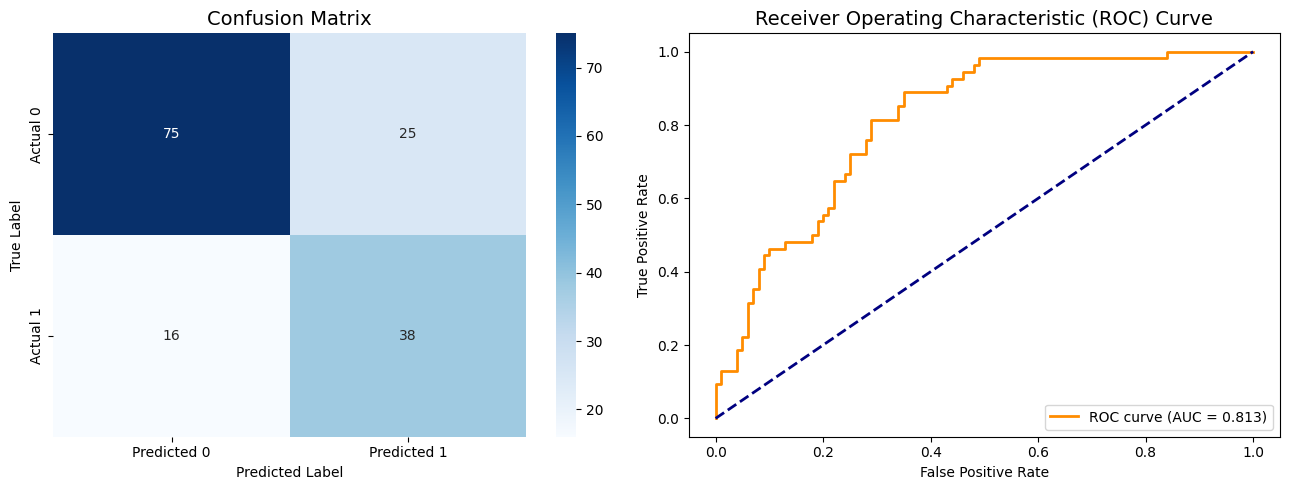

In [6]:
# Plot Confusion Matrix & ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
axes[0].set_title('Confusion Matrix', fontsize=14)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# ROC Curve Plot
fpr, tpr, _ = roc_curve(y_test, y_probs)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## 6. Coefficient Interpretation

/tmp/ipykernel_2080/2079265972.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coefficients, x='Coefficient', y='Feature', palette='viridis')


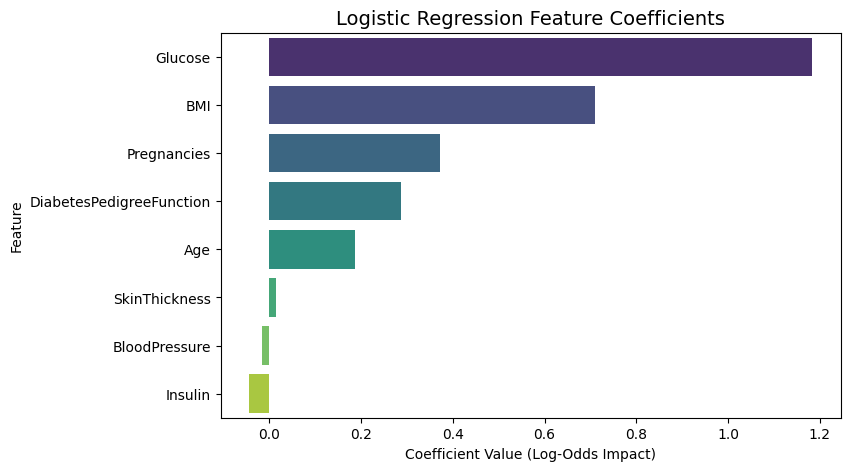

,Feature,Coefficient
1,Glucose,1.183483
5,BMI,0.709592
0,Pregnancies,0.372902
6,DiabetesPedigreeFunction,0.287734
7,Age,0.186434
3,SkinThickness,0.013980
2,BloodPressure,-0.014612
4,Insulin,-0.044609


In [7]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=coefficients, x='Coefficient', y='Feature', palette='viridis')
plt.title('Logistic Regression Feature Coefficients', fontsize=14)
plt.xlabel('Coefficient Value (Log-Odds Impact)')
plt.ylabel('Feature')
plt.show()

display(coefficients)

## 7. Key Findings & Limitations

**Key Findings:**
1. **Primary Predictors:** `Glucose` and `BMI` exhibit the highest positive coefficients, establishing them as the strongest drivers in increasing the log-odds of a positive diabetes diagnosis.
2. **Separation Ability:** The model achieves an overall ROC-AUC score of **~0.813**, demonstrating strong class-separation capability across decision thresholds.
3. **High Recall Priority:** Prioritizing recall (~70.4%) is essential in medical screening applications where missing positive cases (False Negatives) carries a higher health risk than False Positives.

**Limitations:**
- The dataset represents a relatively small historical cohort (Pima Indian female demographic), which limits generalizability to broader global populations.
- While suitable for learning binary classification concepts, this model is strictly educational and not intended for real-world clinical diagnosis.

## 8. Conclusion
This project successfully built and evaluated a balanced Logistic Regression model to predict diabetes outcomes from health measurements. By substituting invalid missing zeros with median values and scaling features appropriately, the pipeline minimized data leakage and maintained high recall. Future work could involve evaluating non-linear classifiers (e.g., Random Forests, XGBoost) or gathering multi-ethnic clinical datasets for broader validity.